In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os, glob, random, shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
random.seed(0)
np.random.seed(0)

Using device: cpu


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile

zip_path = "/content/drive/MyDrive/ASL_Dataset/ASL_Raw_Images.zip"
extract_path = "/content/asl_raw_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted. Top-level contents:")
print(os.listdir(extract_path))


Mounted at /content/drive
Extracted. Top-level contents:
['asl_dataset']


In [ ]:
def find_class_root(root):
    expected = set(list("ABCDEFGHIJKLMNOPQRSTUVWXYZ") + [str(d) for d in range(10)])
    for current, subdirs, _ in os.walk(root):
        overlap = set(subdirs) & expected
        if len(overlap) >= 30:
            return current, sorted(subdirs)
    return None, None

class_root, class_names_found = find_class_root(extract_path)
print("Found class folder at:", class_root)
print("Classes found:", class_names_found)
print("Number of classes found:", len(class_names_found))

Found class folder at: /content/asl_raw_data/asl_dataset
Classes found: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes found: 36


In [ ]:
sample_class = class_names_found[0]
sample_files = os.listdir(os.path.join(class_root, sample_class))
print(f"Class '{sample_class}' has {len(sample_files)} images")
print("First 15 filenames:")
for f in sample_files[:15]:
    print(" ", f)

Class '0' has 1000 images
First 15 filenames:
  P7_0_603.jpg
  P5_0_496.jpg
  P7_0_626.jpg
  P8_0_734.jpg
  P10_0_951.jpg
  P10_0_939.jpg
  P8_0_750.jpg
  P5_0_414.jpg
  P2_0_152.jpg
  P5_0_431.jpg
  P8_0_781.jpg
  P3_0_209.jpg
  P6_0_527.jpg
  P4_0_336.jpg
  P4_0_372.jpg


In [ ]:
import re

ID_PATTERN = re.compile(r"^(P\d+)_")

def extract_group_id(fname):
    m = ID_PATTERN.match(fname)
    return m.group(1) if m else "unknown"

split_root = "/content/asl_raw_split"
train_dir  = os.path.join(split_root, "train")
test_dir   = os.path.join(split_root, "test")


sample_files = os.listdir(os.path.join(class_root, class_names_found[0]))
all_ids = sorted(set(extract_group_id(f) for f in sample_files))
rng = random.Random(0)
rng.shuffle(all_ids)
n_test_ids = max(1, int(len(all_ids) * 0.2))
test_ids = set(all_ids[:n_test_ids])
print("Volunteer ids routed to TEST:", test_ids)

for cls in class_names_found:
    files = os.listdir(os.path.join(class_root, cls))
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)
    for fname in files:
        dest_root = test_dir if extract_group_id(fname) in test_ids else train_dir
        shutil.copy2(os.path.join(class_root, cls, fname), os.path.join(dest_root, cls, fname))

print("Done. Split saved under:", split_root)

Volunteer ids routed to TEST: {'P7', 'P8'}
Done. Split saved under: /content/asl_raw_split


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 64

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_transform)
test_ds  = datasets.ImageFolder(test_dir,  transform=basic_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", train_ds.classes)
print("Number of classes:", NUM_CLASSES)
print("Train images:", len(train_ds))
print("Test images :", len(test_ds))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 36
Train images: 28800
Test images : 7200


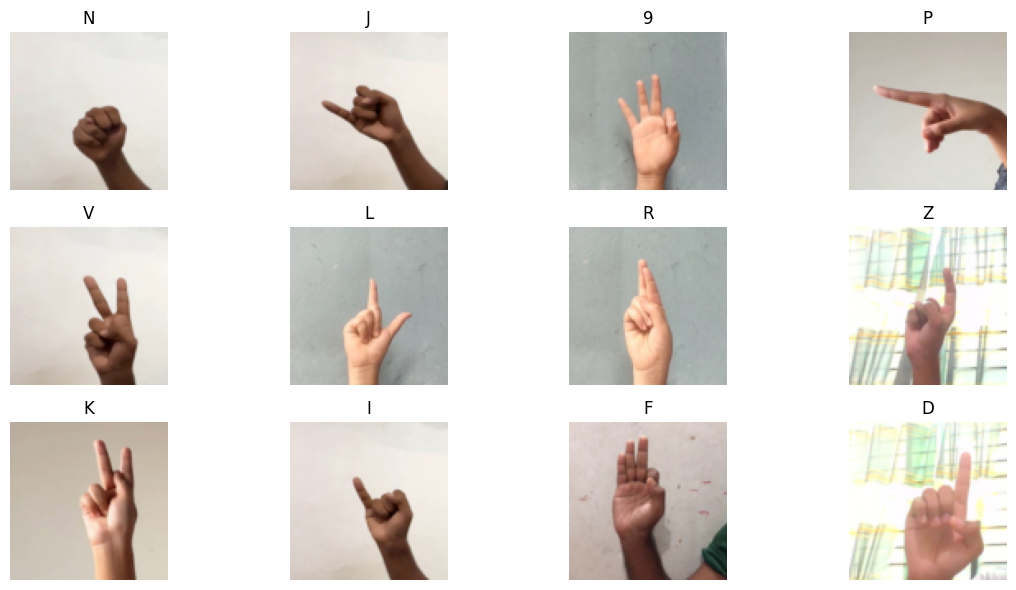

In [ ]:
images, labels = next(iter(train_loader))
class_names = train_ds.classes

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
class ASLCNN(nn.Module):
    def __init__(self, p_dropout=0.0, num_classes=36):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)

        self.dropout = nn.Dropout(p_dropout)
        self.fc1 = nn.Linear(64 * 12 * 12, 256)  # 96 -> 48 -> 24 -> 12
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x


In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss {train_loss:.3f} acc {train_acc:.3f} "
              f"| val_loss {val_loss:.3f} acc {val_acc:.3f}")

    return history

def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"],   "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"],   "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
model = ASLCNN(p_dropout=0.0, num_classes=NUM_CLASSES).to(device)
history_plain = train_model(model, train_loader, test_loader, epochs=20)

Epoch 1/20 | train_loss 0.932 acc 0.739 | val_loss 11.814 acc 0.288
Epoch 2/20 | train_loss 0.029 acc 0.993 | val_loss 6.848 acc 0.329
Epoch 3/20 | train_loss 0.010 acc 0.998 | val_loss 8.681 acc 0.382
Epoch 4/20 | train_loss 0.016 acc 0.996 | val_loss 8.442 acc 0.379
Epoch 5/20 | train_loss 0.000 acc 1.000 | val_loss 9.219 acc 0.372
Epoch 6/20 | train_loss 0.000 acc 1.000 | val_loss 9.623 acc 0.372
Epoch 7/20 | train_loss 0.000 acc 1.000 | val_loss 9.914 acc 0.372
Epoch 8/20 | train_loss 0.000 acc 1.000 | val_loss 10.226 acc 0.368
Epoch 9/20 | train_loss 0.000 acc 1.000 | val_loss 10.441 acc 0.368


KeyboardInterrupt: 

In [ ]:
import re

ID_PATTERN = re.compile(r"^(P\d+)_")

def extract_group_id(fname):
    m = ID_PATTERN.match(fname)
    return m.group(1) if m else "unknown"

split_root = "/content/asl_raw_split"
train_dir  = os.path.join(split_root, "train")
test_dir   = os.path.join(split_root, "test")

# Decide which volunteer ids go to test (about 20% of people, applied consistently
# across all classes so a given person never appears in both train and test)
sample_files = os.listdir(os.path.join(class_root, class_names_found[0]))
all_ids = sorted(set(extract_group_id(f) for f in sample_files))
rng = random.Random(0)
rng.shuffle(all_ids)
n_test_ids = max(1, int(len(all_ids) * 0.2))
test_ids = set(all_ids[:n_test_ids])
print("Volunteer ids routed to TEST:", test_ids)

for cls in class_names_found:
    files = os.listdir(os.path.join(class_root, cls))
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)
    for fname in files:
        dest_root = test_dir if extract_group_id(fname) in test_ids else train_dir
        shutil.copy2(os.path.join(class_root, cls, fname), os.path.join(dest_root, cls, fname))

print("Done. Split saved under:", split_root)

Volunteer ids routed to TEST: {'P7', 'P8'}
Done. Split saved under: /content/asl_raw_split


In [ ]:
IMG_SIZE = 96
BATCH_SIZE = 64

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_transform)
test_ds  = datasets.ImageFolder(test_dir,  transform=basic_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_ds.classes)
print("Classes:", train_ds.classes)
print("Number of classes:", NUM_CLASSES)
print("Train images:", len(train_ds))
print("Test images :", len(test_ds))


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Number of classes: 36
Train images: 28800
Test images : 7200


In [ ]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_running_loss += loss.item() * imgs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | train_loss {train_loss:.3f} acc {train_acc:.3f} "
              f"| val_loss {val_loss:.3f} acc {val_acc:.3f}")

    return history

def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"],   "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"],   "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


Small train subset: 2520 images across 36 classes
Epoch 1/15 | train_loss 3.511 acc 0.069 | val_loss 3.336 acc 0.072
Epoch 2/15 | train_loss 2.695 acc 0.257 | val_loss 3.645 acc 0.140
Epoch 3/15 | train_loss 1.471 acc 0.592 | val_loss 4.586 acc 0.206
Epoch 4/15 | train_loss 0.807 acc 0.772 | val_loss 5.002 acc 0.302
Epoch 5/15 | train_loss 0.408 acc 0.892 | val_loss 5.116 acc 0.264
Epoch 6/15 | train_loss 0.191 acc 0.951 | val_loss 5.648 acc 0.275
Epoch 7/15 | train_loss 0.097 acc 0.976 | val_loss 6.922 acc 0.306
Epoch 8/15 | train_loss 0.127 acc 0.962 | val_loss 6.170 acc 0.306
Epoch 9/15 | train_loss 0.070 acc 0.982 | val_loss 6.636 acc 0.270
Epoch 10/15 | train_loss 0.048 acc 0.988 | val_loss 7.125 acc 0.311
Epoch 11/15 | train_loss 0.035 acc 0.990 | val_loss 6.612 acc 0.334
Epoch 12/15 | train_loss 0.077 acc 0.980 | val_loss 6.794 acc 0.283
Epoch 13/15 | train_loss 0.017 acc 0.997 | val_loss 7.689 acc 0.311
Epoch 14/15 | train_loss 0.005 acc 0.999 | val_loss 7.678 acc 0.348
Epoch 1

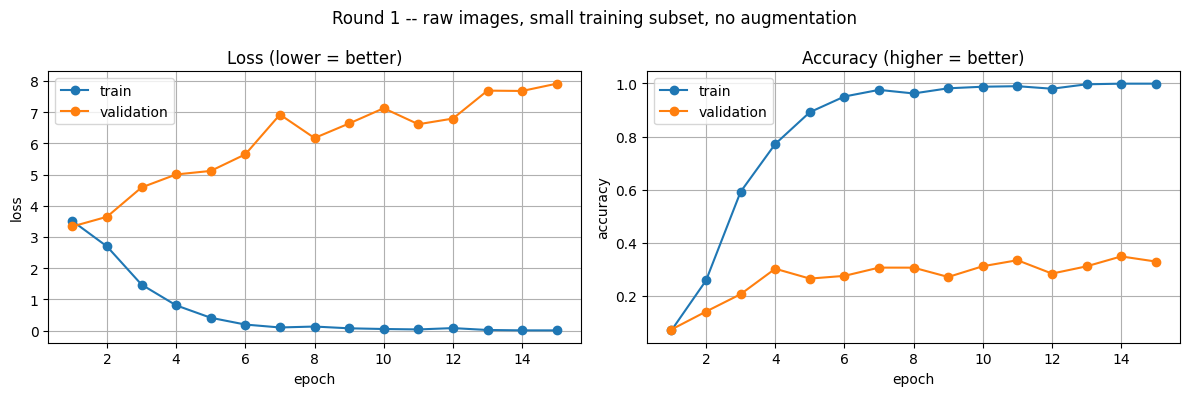

In [ ]:
def per_class_indices(dataset, n, seed=0):
    rng = random.Random(seed)
    buckets = {c: [] for c in range(len(dataset.classes))}
    for idx, (_, label) in enumerate(dataset.samples):
        buckets[label].append(idx)
    chosen = []
    for c, idxs in buckets.items():
        rng.shuffle(idxs)
        chosen.extend(idxs[:n])
    return chosen

SMALL_PER_CLASS = 70
small_idx = per_class_indices(train_ds, SMALL_PER_CLASS, seed=0)
train_ds_small = Subset(train_ds, small_idx)
train_loader_small = DataLoader(train_ds_small, batch_size=BATCH_SIZE, shuffle=True)
print("Small train subset:", len(train_ds_small), "images across", NUM_CLASSES, "classes")

# re-run
model = ASLCNN(p_dropout=0.0, num_classes=NUM_CLASSES).to(device)
history_plain = train_model(model, train_loader_small, test_loader, epochs=15)
plot_history(history_plain, "Round 1 -- raw images, small training subset, no augmentation")

In [ ]:
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
])


val_transform_clean = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds_aug  = datasets.ImageFolder(train_dir, transform=train_transform_aug)
test_ds_clean = datasets.ImageFolder(test_dir,  transform=val_transform_clean)


train_ds_aug = Subset(train_ds_aug, small_idx)

train_loader_aug  = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
test_loader_clean = DataLoader(test_ds_clean, batch_size=BATCH_SIZE, shuffle=False)

Epoch 1/30 | train_loss 3.586 acc 0.026 | val_loss 3.574 acc 0.086
Epoch 2/30 | train_loss 3.533 acc 0.055 | val_loss 3.376 acc 0.088
Epoch 3/30 | train_loss 3.380 acc 0.088 | val_loss 3.212 acc 0.155
Epoch 4/30 | train_loss 3.210 acc 0.126 | val_loss 2.994 acc 0.174
Epoch 5/30 | train_loss 3.033 acc 0.157 | val_loss 2.878 acc 0.224
Epoch 6/30 | train_loss 2.874 acc 0.185 | val_loss 2.763 acc 0.218
Epoch 7/30 | train_loss 2.712 acc 0.212 | val_loss 2.744 acc 0.188
Epoch 8/30 | train_loss 2.513 acc 0.261 | val_loss 2.451 acc 0.249
Epoch 9/30 | train_loss 2.409 acc 0.267 | val_loss 2.239 acc 0.348
Epoch 10/30 | train_loss 2.306 acc 0.302 | val_loss 2.172 acc 0.359
Epoch 11/30 | train_loss 2.167 acc 0.322 | val_loss 2.082 acc 0.378
Epoch 12/30 | train_loss 2.037 acc 0.361 | val_loss 2.080 acc 0.371
Epoch 13/30 | train_loss 1.964 acc 0.384 | val_loss 1.965 acc 0.406
Epoch 14/30 | train_loss 1.839 acc 0.417 | val_loss 1.951 acc 0.379
Epoch 15/30 | train_loss 1.783 acc 0.436 | val_loss 1.958

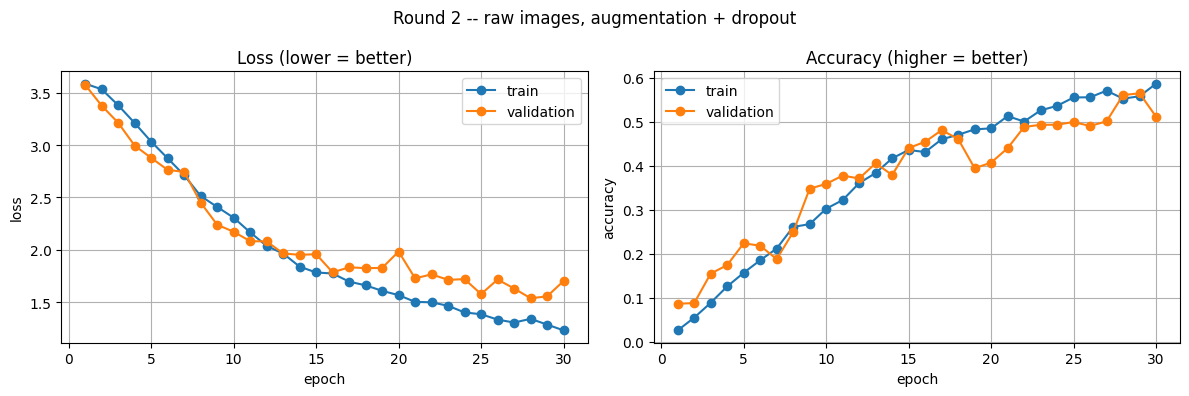

In [ ]:
model_aug = ASLCNN(p_dropout=0.5, num_classes=NUM_CLASSES).to(device)
history_aug = train_model(model_aug, train_loader_aug, test_loader_clean,
                           epochs=30)

plot_history(history_aug, "Round 2 -- raw images, augmentation + dropout")

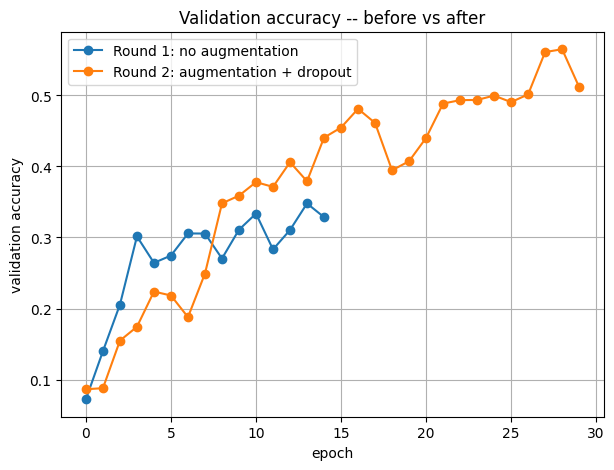

Best val acc   (Round 1): 0.348
Best val acc   (Round 2): 0.565
Final train-val accuracy gap (Round 1, no augmentation): 0.671
Final train-val accuracy gap (Round 2, augmentation+dropout): 0.075


In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(history_plain["val_acc"], "o-", label="Round 1: no augmentation")
plt.plot(history_aug["val_acc"],   "o-", label="Round 2: augmentation + dropout")
plt.title("Validation accuracy -- before vs after")
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(True)
plt.show()

gap_plain = history_plain["train_acc"][-1] - history_plain["val_acc"][-1]
gap_aug   = history_aug["train_acc"][-1]   - history_aug["val_acc"][-1]

print(f"Best val acc   (Round 1): {max(history_plain['val_acc']):.3f}")
print(f"Best val acc   (Round 2): {max(history_aug['val_acc']):.3f}")
print(f"Final train-val accuracy gap (Round 1, no augmentation): {gap_plain:.3f}")
print(f"Final train-val accuracy gap (Round 2, augmentation+dropout): {gap_aug:.3f}")


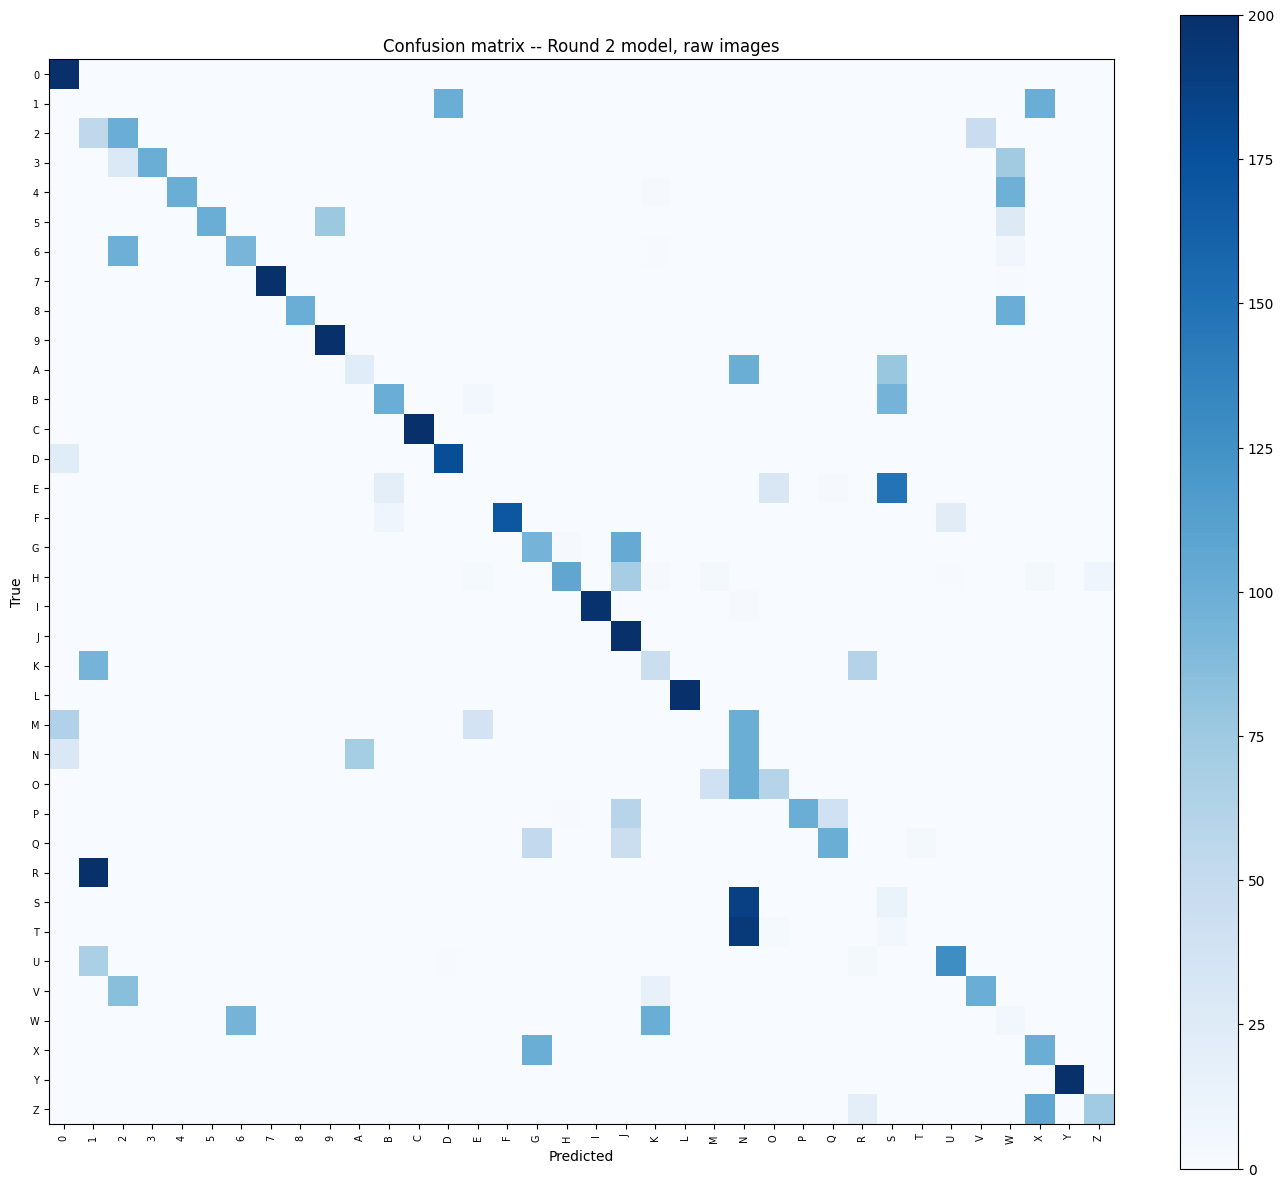

              precision    recall  f1-score   support

           0       0.63      1.00      0.78       200
           1       0.00      0.00      0.00       200
           2       0.32      0.50      0.39       200
           3       1.00      0.50      0.67       200
           4       1.00      0.50      0.67       200
           5       1.00      0.50      0.67       200
           6       0.49      0.47      0.48       200
           7       1.00      0.99      1.00       200
           8       1.00      0.50      0.67       200
           9       0.73      1.00      0.84       200
           A       0.24      0.12      0.16       200
           B       0.78      0.50      0.61       200
           C       1.00      1.00      1.00       200
           D       0.64      0.89      0.74       200
           E       0.00      0.00      0.00       200
           F       1.00      0.85      0.92       200
           G       0.38      0.47      0.43       200
           H       0.97    

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds.append(outputs.argmax(1).cpu())
            targets.append(labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

y_pred, y_true = get_predictions(model_aug, test_loader_clean)
class_names = test_ds_clean.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(class_names)), class_names, rotation=90, fontsize=7)
plt.yticks(range(len(class_names)), class_names, fontsize=7)
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion matrix -- Round 2 model, raw images")
plt.colorbar()
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))